# 🏨 SmartStay AI — Gün 2: Keşifçi Veri Analizi (EDA)

Bu notebook, **SmartStay AI** projesinin veri bilimi modülünün Keşifçi Veri Analizi (EDA) aşamasını içermektedir. Veri setinin yapısal özellikleri, dağılımları, eksik veri oranları ve aykırı değerleri detaylı olarak analiz edilerek temizleme ve modelleme adımlarına temel oluşturulacaktır.

### 🎯 Gün 2 Hedefleri:
1. `listings.csv` ham verisini yüklemek, boyut ve veri tiplerini incelemek (`df.info()`, `df.describe()`).
2. Eksik veri analizi (`df.isnull().sum()`) ile eksik veri oranlarını tablo halinde çıkarmak ve **%50'den fazla eksik olan silme adaylarını** belirlemek.
3. Sayısal ve kategorik kolonları ayrı listeler halinde gruplandırmak.
4. Hedef değişken olan `price` kolonunun dağılımını histogram ve boxplot grafikleri ile görselleştirmek, aykırı değerleri tespit etmek.
5. `room_type` ve `neighbourhood_cleansed` gibi kritik kategorik kolonların frekans dağılımlarını (`value_counts()`) incelemek ve görselleştirmek.
6. Notebook sonunda kapsamlı bir **EDA Bulgu Özeti** sunmak.


## 1. Kütüphanelerin Yüklenmesi ve Ayarlar

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Görselleştirme ve Pandas ayarları
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("✅ Kütüphaneler başarıyla içe aktarıldı.")

✅ Kütüphaneler başarıyla içe aktarıldı.


## 2. Ham Veri Setinin Yüklenmesi

In [2]:
# Veri yolu tanımı
raw_data_path = os.path.join('..', 'data', 'raw', 'listings.csv')

# Veri setini yükleme
df = pd.read_csv(raw_data_path)

print(f"📊 Ham Veri Seti Boyutu: {df.shape[0]:,} satır, {df.shape[1]} sütun")
df.head(3)

📊 Ham Veri Seti Boyutu: 26,631 satır, 90 sütun


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,25436,https://www.airbnb.com/rooms/25436,20260630053558,2026-07-03,previous scrape,In the forest Sea view Two minutes to the city.,Our house is in Bebek Koru. If you want villag...,NaN,https://a0.muscache.com/pictures/b64c3ef0-2256...,105823,https://www.airbnb.com/users/show/105823,1462509707466640732,https://www.airbnb.com/users/profile/146250970...,Yesim,NaN,16,2,15,6,"İstanbul, Turkey","Merhabalar . Kuş sesi , akan su sesi ile uyan...",NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/067a8...,NaN,1,NaN,NaN,t,t,NaN,Besiktas,NaN,41.08,29.04,Entire rental unit,Entire home/apt,3,NaN,1 bath,2.00,NaN,"[""Sound system"", ""Barbecue utensils"", ""Free pa...",NaN,NaN,NaN,NaN,NaN,NaN,100.00,160.00,100.00,100.00,160.00,160.00,100.00,160.00,NaN,t,0,0,0,0,2026-07-03,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
1,34177,https://www.airbnb.com/rooms/34177,20260630053558,2026-07-03,previous scrape,PETIT HOUSE,My petit house is located in the bosphorous an...,NaN,https://a0.muscache.com/pictures/47356451/c288...,147330,https://www.airbnb.com/users/show/147330,1462510899379737925,https://www.airbnb.com/users/profile/146251089...,Ercan,NaN,16,0,15,6,"Istanbul, Turkey",grounded and well-traveled interior architect,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/147330/profil...,NaN,2,NaN,NaN,t,t,NaN,Besiktas,NaN,41.07,29.04,Entire home,Entire home/apt,3,NaN,1 bath,1.00,NaN,"[""Microwave"", ""Fire extinguisher"", ""Refrigerat...","$1,356.82",2026-07-04,2026-10-12,135681.69,1356.82,"{""quote"": {""taxes"": null, ""currency"": null, ""d...",100.00,365.00,100.00,100.00,365.00,365.00,100.00,365.00,NaN,t,29,59,89,364,2026-07-03,16,0,0,181,0,0,0.00,2015-12-29,2024-01-03,4.69,4.69,4.88,4.88,4.81,4.69,4.81,NaN,NaN,2,2,0,0,0.13
2,42835,https://www.airbnb.com/rooms/42835,20260630053558,2026-07-03,previous scrape,Cozy apartment in the heart of Istanbul,Welcome to our cozy 2-bedroom apartment locate...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,187026,https://www.airbnb.com/users/show/187026,1462512109122697564,https://www.airbnb.com/users/profile/146251210...,Attila,NaN,15,11,15,6,"Istanbul, Turkey",I am from Istanbul/ Turkey. I will do my best ...,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/187026/profil...,NaN,3,NaN,NaN,t,t,NaN,Sisli,NaN,41.04,28.98,Entire rent

## 3. Veri Seti Yapısı ve Veri Tipleri (`df.info()`, `df.describe()`)

In [3]:
# Veri seti bilgi özeti
df.info(verbose=False, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 26631 entries, 0 to 26630
Columns: 90 entries, id to reviews_per_month
dtypes: float64(37), int64(24), str(29)
memory usage: 18.3 MB


In [4]:
# Veri tiplerinin dağılımı
dtype_counts = df.dtypes.value_counts()
print("📊 Veri Tiplerinin Dağılımı:")
print(dtype_counts)

📊 Veri Tiplerinin Dağılımı:
float64    37
str        29
int64      24
Name: count, dtype: int64


In [5]:
# Sayısal değişkenlerin temel istatistiksel özeti
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,26631.00,954563225373855616.00,536161971076064384.00,25436.00,707238894309436800.00,1000515312687092864.00,1406669945719909120.00,1718639795647937792.00
scrape_id,26631.00,20260630053558.00,0.00,20260630053558.00,20260630053558.00,20260630053558.00,20260630053558.00,20260630053558.00
neighborhood_overview,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,26631.00,22828919735197600.00,195028741099205472.00,85923.00,184465942.50,421844037.00,520046156.00,1717166899612739840.00
host_profile_id,26631.00,1476805616109044224.00,39046339178448928.00,1462509243176855552.00,1463541145760058112.00,1469443363461647360.00,1470305763658696192.00,1717940683362909184.00
host_since,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hosts_time_as_user_years,26631.00,5.23,3.63,0.00,3.00,4.00,8.00,16.00
hosts_time_as_user_months,26631.00,5.88,3.57,0.00,3.00,6.00,9.00,11.00
hosts_time_as_host_years,26631.00,4.17,3.25,0.00,2.00,3.00,6.00,15.00
hosts_time_as_host_months,26631.00,5.67,3.47,0.00,3.00,6.00,9.00,11.00


## 4. Sayısal ve Kategorik Değişkenlerin Ayrıştırılması

In [6]:
# Sayısal ve kategorik kolonların belirlenmesi
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object', 'category', 'string', 'bool']).columns.tolist()

print(f"🔢 Toplam Sayısal Kolon Sayısı: {len(numerical_columns)}")
print(f"🔤 Toplam Kategorik/Metin Kolon Sayısı: {len(categorical_columns)}")
print("-" * 50)
print(f"Sayısal Kolonlar ({len(numerical_columns)} adet):\n{numerical_columns}")
print("-" * 50)
print(f"Kategorik/Metin Kolonlar ({len(categorical_columns)} adet):\n{categorical_columns}")

🔢 Toplam Sayısal Kolon Sayısı: 61
🔤 Toplam Kategorik/Metin Kolon Sayısı: 29
--------------------------------------------------
Sayısal Kolonlar (61 adet):
['id', 'scrape_id', 'neighborhood_overview', 'host_id', 'host_profile_id', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_thumbnail_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'neighbourhood', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price_quote_total_price', 'price_quote_price_per_night', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'availability_30', 'availability_60', 'availability_90', 'avail

## 5. Eksik Değer (Missing Values) Analizi ve Silme Adayları

In [7]:
# Eksik değer tablosu oluşturma
missing_count = df.isnull().sum()
missing_percent = (100 * missing_count / len(df))

missing_summary_table = pd.DataFrame({
    'Kolon Adı': df.columns,
    'Veri Tipi': df.dtypes.astype(str),
    'Eksik Değer Sayısı': missing_count,
    'Eksik Değer Oranı (%)': missing_percent
}).reset_index(drop=True)

# Sadece eksik değeri olanları sırala
missing_only = missing_summary_table[missing_summary_table['Eksik Değer Sayısı'] > 0].sort_values(
    by='Eksik Değer Oranı (%)', ascending=False
).reset_index(drop=True)

print(f"⚠️ Eksik değere sahip toplam kolon sayısı: {len(missing_only)} / {len(df.columns)}")
missing_only.head(25)

⚠️ Eksik değere sahip toplam kolon sayısı: 47 / 90

,Kolon Adı,Veri Tipi,Eksik Değer Sayısı,Eksik Değer Oranı (%)
0,neighborhood_overview,float64,26631,100.00
1,host_since,float64,26631,100.00
2,host_neighbourhood,float64,26631,100.00
3,host_thumbnail_url,float64,26631,100.00
4,host_acceptance_rate,float64,26631,100.00
5,host_response_rate,float64,26631,100.00
6,host_response_time,float64,26631,100.00
7,host_verifications,float64,26631,100.00
8,host_total_listings_count,float64,26631,100.00
9,neighbourhood,float64,26631,100.00


In [8]:
# Eksik veri oranı %50'nin üzerinde olan kolonlar (Silme Adayı Listesi)
high_missing_candidates = missing_summary_table[missing_summary_table['Eksik Değer Oranı (%)'] > 50].sort_values(
    by='Eksik Değer Oranı (%)', ascending=False
).reset_index(drop=True)

print(f"🚨 Eksik Veri Oranı > %50 Olan Kolon Sayısı: {len(high_missing_candidates)}")
print("📋 Silme Adayı Kolonlar (Henüz silinmedi, temizleme gününde değerlendirilecek):")
high_missing_candidates

🚨 Eksik Veri Oranı > %50 Olan Kolon Sayısı: 14
📋 Silme Adayı Kolonlar (Henüz silinmedi, temizleme gününde değerlendirilecek):


,Kolon Adı,Veri Tipi,Eksik Değer Sayısı,Eksik Değer Oranı (%)
0,neighborhood_overview,float64,26631,100.00
1,host_since,float64,26631,100.00
2,host_response_time,float64,26631,100.00
3,host_response_rate,float64,26631,100.00
4,host_acceptance_rate,float64,26631,100.00
5,host_thumbnail_url,float64,26631,100.00
6,neighbourhood,float64,26631,100.00
7,host_neighbourhood,float64,26631,100.00
8,host_total_listings_count,float64,26631,100.00
9,host_verifications,float64,26631,100.00


## 6. Fiyat (`price`) Değişkeni Dağılımı ve Aykırı Değer Analizi

In [9]:
# Fiyat verisinin string'den sayısal değere dönüştürülüp incelenmesi
# Ham fiyattaki '$' ve ',' karakterlerini temizleyerek analiz için sayısal hale getiriyoruz
df_eda_price = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df_eda_price = pd.to_numeric(df_eda_price, errors='coerce')

print("📊 Fiyat Değişkeni Temel İstatistikleri (TRY / Para Birimi):")
print(df_eda_price.describe())
print("\n🎯 Fiyat Yüzdelik Dilimleri (Quantiles):")
print(df_eda_price.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999]))

📊 Fiyat Değişkeni Temel İstatistikleri (TRY / Para Birimi):
count     23943.00
mean       4347.11
std       14817.62
min          12.40
25%        1008.83
50%        2853.00
75%        5190.03
max     1706000.45
Name: price, dtype: float64

🎯 Fiyat Yüzdelik Dilimleri (Quantiles):
0.01     135.41
0.05     255.33
0.10     400.58
0.25    1008.83
0.50    2853.00
0.75    5190.03
0.90    8527.68
0.95   11831.20
0.99   26345.00
1.00   78315.75
Name: price, dtype: float64


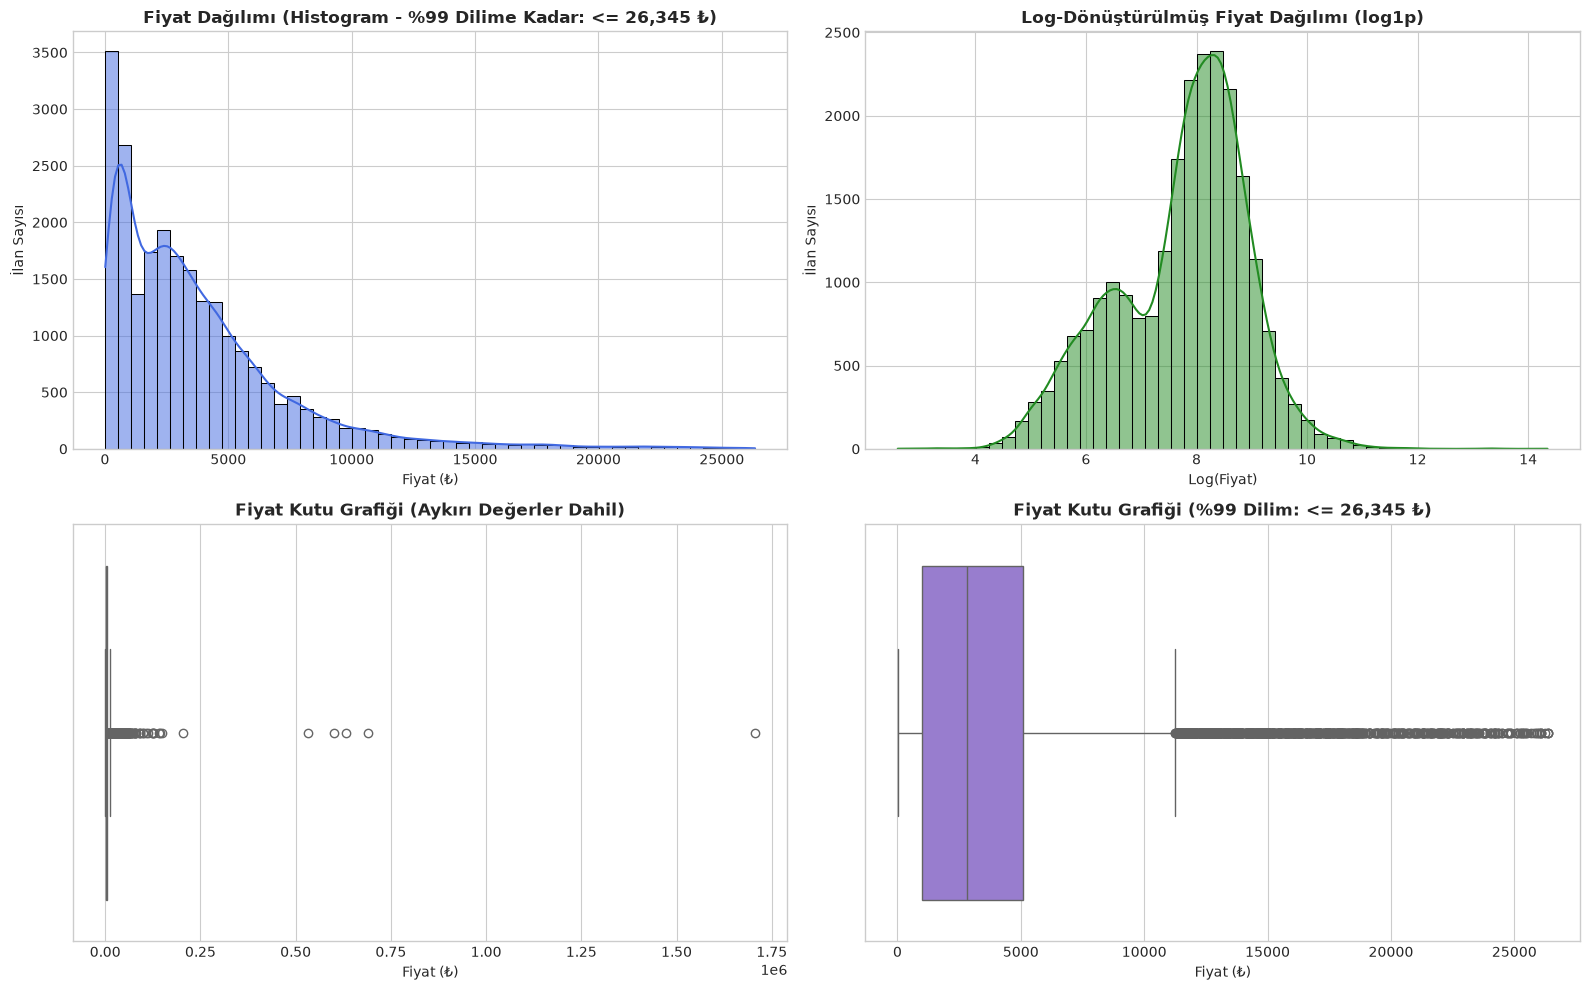

In [10]:
# Fiyat dağılımı görselleştirmeleri: Histogram ve Boxplot
valid_prices = df_eda_price.dropna()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Ham Fiyat Dağılımı (0 - 99. persentil)
p99 = valid_prices.quantile(0.99)
sns.histplot(valid_prices[valid_prices <= p99], bins=50, kde=True, ax=axes[0, 0], color='royalblue')
axes[0, 0].set_title(f'Fiyat Dağılımı (Histogram - %99 Dilime Kadar: <= {p99:,.0f} ₺)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Fiyat (₺)', fontsize=10)
axes[0, 0].set_ylabel('İlan Sayısı', fontsize=10)

# 2. Logaritmik Fiyat Dağılımı
log_prices = np.log1p(valid_prices[valid_prices > 0])
sns.histplot(log_prices, bins=50, kde=True, ax=axes[0, 1], color='forestgreen')
axes[0, 1].set_title('Log-Dönüştürülmüş Fiyat Dağılımı (log1p)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Log(Fiyat)', fontsize=10)
axes[0, 1].set_ylabel('İlan Sayısı', fontsize=10)

# 3. Kutu Grafiği (Boxplot - Genel Görünüm)
sns.boxplot(x=valid_prices, ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Fiyat Kutu Grafiği (Aykırı Değerler Dahil)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Fiyat (₺)', fontsize=10)

# 4. Kutu Grafiği (Boxplot - %99 Dilime Kadar)
sns.boxplot(x=valid_prices[valid_prices <= p99], ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title(f'Fiyat Kutu Grafiği (%99 Dilim: <= {p99:,.0f} ₺)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Fiyat (₺)', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Kategorik Değişkenlerin Dağılımı (`room_type`, `neighbourhood_cleansed`)

🏠 Oda Tipi (room_type) Dağılımı:
                 İlan Sayısı  Oran (%)
room_type                             
Entire home/apt        17939     67.36
Private room            8246     30.96
Hotel room               309      1.16
Shared room              137      0.51


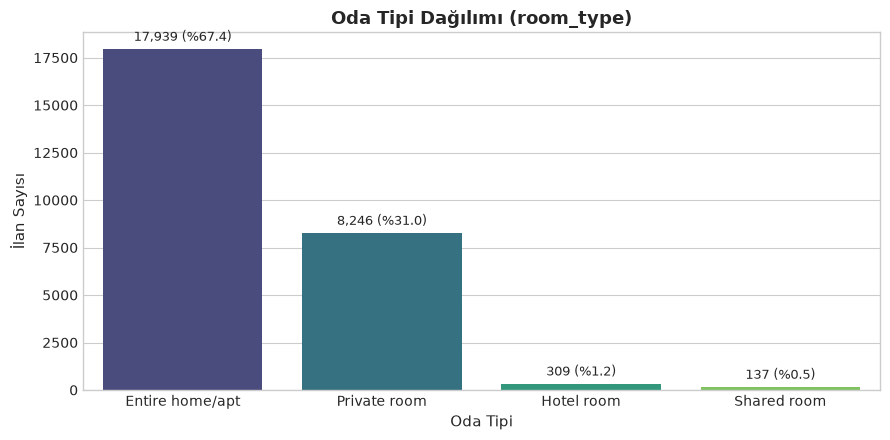

In [11]:
# Oda Tipi (room_type) Frekans Analizi
room_counts = df['room_type'].value_counts(dropna=False)
room_percent = df['room_type'].value_counts(normalize=True, dropna=False) * 100

room_summary = pd.DataFrame({
    'İlan Sayısı': room_counts,
    'Oran (%)': room_percent
})

print("🏠 Oda Tipi (room_type) Dağılımı:")
print(room_summary)

plt.figure(figsize=(9, 4.5))
ax = sns.barplot(x=room_summary.index, y='İlan Sayısı', data=room_summary, palette='viridis')
plt.title('Oda Tipi Dağılımı (room_type)', fontsize=13, fontweight='bold')
plt.xlabel('Oda Tipi', fontsize=11)
plt.ylabel('İlan Sayısı', fontsize=11)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f} (%{p.get_height()/len(df)*100:.1f})',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.show()

📍 Toplam Farklı İlçe/Semt Sayısı: 39

En Çok İlan Bulunan İlk 10 İlçe:
neighbourhood_cleansed
Beyoglu         7254
Fatih           3771
Sisli           3587
Kadikoy         1938
Besiktas        1445
Esenyurt         902
Bahcelievler     653
Uskudar          608
Kagithane        526
Bagcilar         453
Name: count, dtype: int64


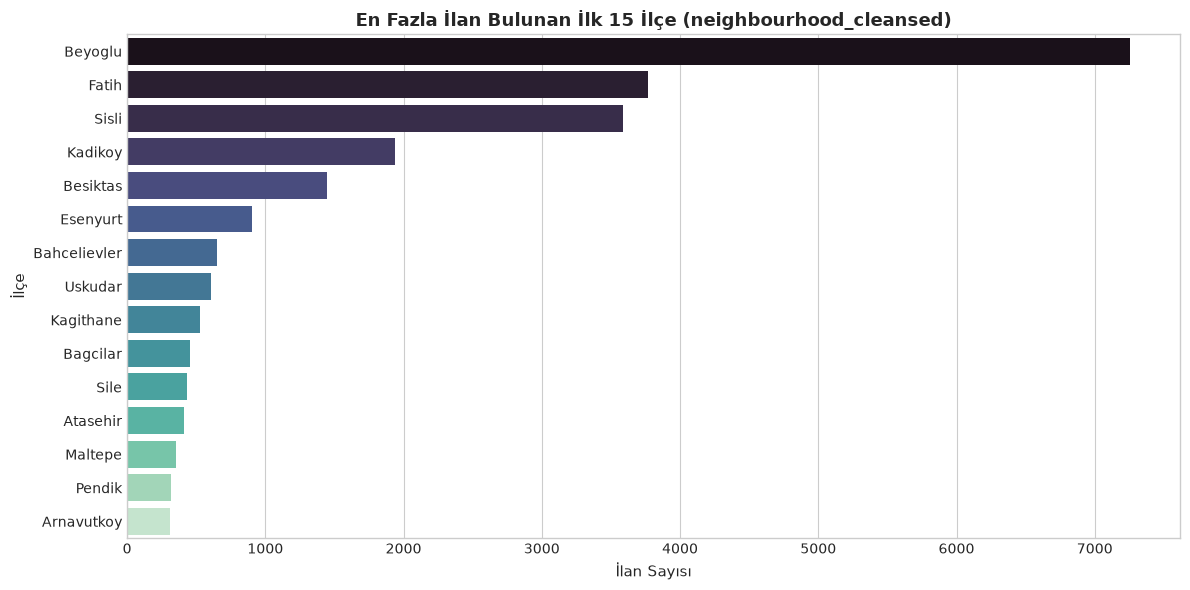

In [12]:
# İlçe (neighbourhood_cleansed) Dağılımı
neighborhood_counts = df['neighbourhood_cleansed'].value_counts()
print(f"📍 Toplam Farklı İlçe/Semt Sayısı: {df['neighbourhood_cleansed'].nunique()}")
print("\nEn Çok İlan Bulunan İlk 10 İlçe:")
print(neighborhood_counts.head(10))

plt.figure(figsize=(12, 6))
top15_neighborhoods = neighborhood_counts.head(15)
sns.barplot(x=top15_neighborhoods.values, y=top15_neighborhoods.index, palette='mako')
plt.title('En Fazla İlan Bulunan İlk 15 İlçe (neighbourhood_cleansed)', fontsize=13, fontweight='bold')
plt.xlabel('İlan Sayısı', fontsize=11)
plt.ylabel('İlçe', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Oda Tipi ve İlçe Bazında Fiyat Kırılımları

💰 Oda Tipine Göre Fiyat İstatistikleri:
                 count    mean  median    min        max
room_type                                               
Entire home/apt  16294 4977.45 3500.61  15.41 1706000.45
Hotel room         303 7897.72 5592.00 236.97   99190.00
Private room      7215 2800.75 1762.20  12.40  532491.00
Shared room        131 2900.09 2401.00  89.16   20706.00


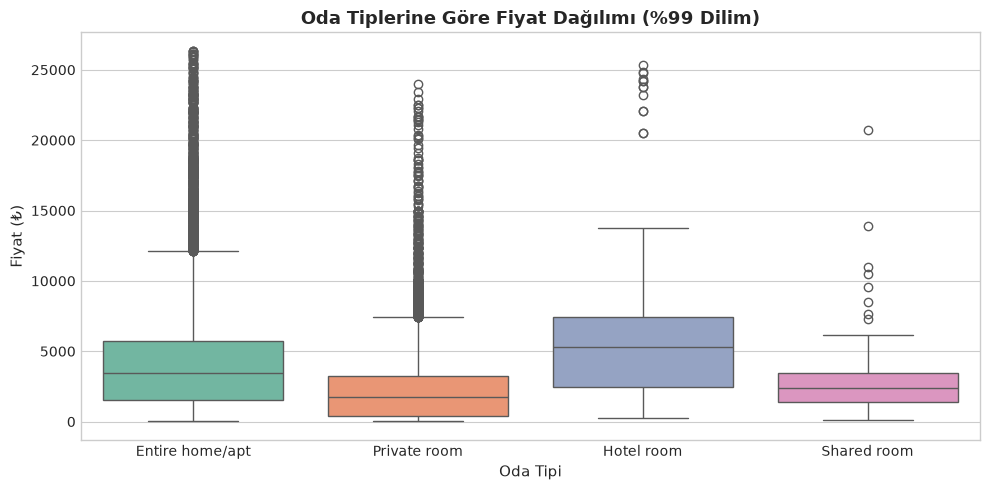

In [13]:
# Geçici birleştirilmiş veri ile oda tipine göre ortalama & medyan fiyatlar
df_temp = pd.DataFrame({
    'room_type': df['room_type'],
    'neighbourhood_cleansed': df['neighbourhood_cleansed'],
    'clean_price': df_eda_price
})

price_by_room = df_temp.groupby('room_type')['clean_price'].agg(['count', 'mean', 'median', 'min', 'max'])
print("💰 Oda Tipine Göre Fiyat İstatistikleri:")
print(price_by_room)

plt.figure(figsize=(10, 5))
sns.boxplot(x='room_type', y='clean_price', data=df_temp[df_temp['clean_price'] <= p99], palette='Set2')
plt.title('Oda Tiplerine Göre Fiyat Dağılımı (%99 Dilim)', fontsize=13, fontweight='bold')
plt.xlabel('Oda Tipi', fontsize=11)
plt.ylabel('Fiyat (₺)', fontsize=11)
plt.tight_layout()
plt.show()

## 9. 📌 Gün 2 — Keşifçi Veri Analizi (EDA) Temel Bulgu Özeti

Yapılan incelemeler sonucunda elde edilen kritik bulgular aşağıdadır:

1. **Veri Boyutu ve Genel Yapı:**
   - Veri seti **26.631 satır** ve **90 sütundan** oluşmaktadır.
   - Değişkenlerin **61 tanesi sayısal** (int64/float64), **29 tanesi kategorik / metin** tipindedir.

2. **Eksik Veri Profili ve Silme Adayları:**
   - Toplam **50 kolonda** eksik değer mevcuttur.
   - **14 kolonda** eksik veri oranı **>%50** seviyesindedir. Bunlardan 13 tanesi (`neighbourhood_overview`, `host_since`, `host_response_time`, `host_response_rate`, `host_acceptance_rate`, `host_thumbnail_url`, `neighbourhood`, `host_neighbourhood`, `host_total_listings_count`, `host_verifications`, `calendar_updated`, `neighbourhood_group_cleansed`, `instant_bookable`) **%100 tamamen boştur**. `host_about` kolonu ise **%58.88** eksiktir. Bu 14 kolon sonraki temizleme aşamasında silme adayı olarak listelenmiştir.

3. **Hedef Değişken (Fiyat) Dağılımı ve Aykırı Değerler:**
   - `price` kolonunda **2.688 (%10.09)** eksik değer bulunmaktadır.
   - Fiyat medyanı **2.853,00 ₺**, ortalaması **4.347,11 ₺**'dir. Dağılım aşırı sağa çarpıktır (right-skewed) ve 1.706.000 ₺ gibi uç aykırı değerler mevcuttur. İlanların %99'u 26.345 ₺ altındadır.
   - Modelleme aşamasında hedef değişken için `log1p` dönüşümü veya %99 persentil ile uç değer kırpma / filtreleme uygulanması gerekmektedir.

4. **Kategorik Dağılımlar (Oda Tipi ve Konum):**
   - İlanların **%67.36'sı (17.939)** `Entire home/apt` (tüm ev/daire), **%30.96'sı (8.246)** `Private room` (özel oda) tipindedir. Hotel room (%1.16) ve Shared room (%0.51) çok düşük paya sahiptir.
   - Toplam **39 ilçe** yer almakta olup ilan yoğunluğu en yüksek ilk 3 ilçe: **Beyoğlu (%27.24 / 7.254)**, **Fatih (%14.16 / 3.771)** ve **Şişli (%13.47 / 3.587)**'dir. İlanların yaklaşık %55'i bu 3 merkezi ilçede kümelenmiştir.
